In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf 
import scipy.sparse as sp
from recommenders.evaluation.python_evaluation import (
    map_at_k,
    ndcg_at_k,
    precision_at_k,
    recall_at_k,
)

import LightGCN
from utils import get_top_k_scored_items, nCoreReduction, user_fixed_train_test_split

import matplotlib.pyplot as plt 

import importlib 

import ActiveLearner

## Load data

In [2]:
data_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
data_columns = ['user_id', 'item_id', 'rating', 'timestamp']

user_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.user"
user_columns = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

In [3]:
data_df = pd.read_csv(data_url, sep='\t', names=data_columns, header=None)
user_df = pd.read_csv(user_url, sep='|', names=user_columns, header=None)

In [4]:
# shuffle data_df
data_df = data_df.sample(frac=1, random_state=42).reset_index(drop=True)

## Convert to implicit feedback

**Note**: For MovieLens 100k dataset, we are converting a rating in the range [1, 5] to an implicit feedback of 1 so that we still have a significant number of positive samples in the dataset. For MovieLens 1M, we could do [3, 5] instead.

In [5]:
data_df['rating'] = (data_df['rating'] >= 1).astype(int)

## Dimensionality reduction

Only keep:
- users that provided at least 5 ratings
- items that received at least 5 ratings

In [6]:
ncore_data_df = nCoreReduction(data_df)

In [7]:
print(f"The original data frame shape: {data_df.shape}")
print(f"  - # users: {data_df['user_id'].nunique()}")
print(f"  - # items: {data_df['item_id'].nunique()}")
print('\n')

print(f"The filtered data frame shape: {ncore_data_df.shape}")
print(f"  - # users: {ncore_data_df['user_id'].nunique()}")
print(f"  - # items: {ncore_data_df['item_id'].nunique()}")

The original data frame shape: (100000, 4)
  - # users: 943
  - # items: 1682


The filtered data frame shape: (99032, 4)
  - # users: 943
  - # items: 1298


## Convert id to inner id

In [8]:
unique_users = ncore_data_df['user_id'].unique()
user_id_to_iid = {id: iid for iid, id in enumerate(unique_users)}
user_iid_to_id = {iid: id for iid, id in enumerate(unique_users)}

unique_items = ncore_data_df['item_id'].unique()
item_id_to_iid = {id: iid for iid, id in enumerate(unique_items)}
item_iid_to_id = {iid: id for iid, id in enumerate(unique_items)}

In [9]:
n_users = unique_users.shape[0]
n_items = unique_items.shape[0]

In [10]:
ncore_data_df['user_iid'] = ncore_data_df['user_id'].map(user_id_to_iid)
ncore_data_df['item_iid'] = ncore_data_df['item_id'].map(item_id_to_iid)

# apply to `user_df`` as well
user_df['user_iid'] = user_df['user_id'].map(user_id_to_iid)

In [13]:
iid_to_gender = dict(zip(user_df['user_iid'], user_df['gender']))

## Train test split (user-fixed)

In [14]:
train_df, test_df = user_fixed_train_test_split(ncore_data_df, test_size=0.2, random_state=42)

## Train the model

In [15]:
hparams = {
    'epochs': 50,
    'learning_rate': 0.001,
    'embed_size': 32,
    'batch_size': 1024,
    'n_layers': 3,
    'decay': 0.0001,
    'eval_epoch': -1,
    'top_k': 10,
}

In [71]:
importlib.reload(LightGCN)

<module 'LightGCN' from '/Users/sipei/Tufts/Research/AL/LightGCN.py'>

In [72]:
model = LightGCN.LightGCNRecommender(hparams, train_df, test_df, n_users, n_items, seed=42)

In [73]:
model.fit()

Epoch 1: Loss=0.34981 = (MF_Loss)0.34325 + (Emb_Loss)0.00656
Epoch 2: Loss=0.25204 = (MF_Loss)0.24072 + (Emb_Loss)0.01132
Epoch 3: Loss=0.22726 = (MF_Loss)0.21264 + (Emb_Loss)0.01462
Epoch 4: Loss=0.21657 = (MF_Loss)0.19968 + (Emb_Loss)0.01689
Epoch 5: Loss=0.20920 = (MF_Loss)0.19041 + (Emb_Loss)0.01879
Epoch 6: Loss=0.19881 = (MF_Loss)0.17806 + (Emb_Loss)0.02074
Epoch 7: Loss=0.19384 = (MF_Loss)0.17102 + (Emb_Loss)0.02282
Epoch 8: Loss=0.18594 = (MF_Loss)0.16103 + (Emb_Loss)0.02491
Epoch 9: Loss=0.18260 = (MF_Loss)0.15582 + (Emb_Loss)0.02678
Epoch 10: Loss=0.17796 = (MF_Loss)0.14932 + (Emb_Loss)0.02864
Epoch 11: Loss=0.17597 = (MF_Loss)0.14572 + (Emb_Loss)0.03025
Epoch 12: Loss=0.17191 = (MF_Loss)0.14007 + (Emb_Loss)0.03184
Epoch 13: Loss=0.16676 = (MF_Loss)0.13336 + (Emb_Loss)0.03340
Epoch 14: Loss=0.16562 = (MF_Loss)0.13080 + (Emb_Loss)0.03482
Epoch 15: Loss=0.16283 = (MF_Loss)0.12679 + (Emb_Loss)0.03604
Epoch 16: Loss=0.16017 = (MF_Loss)0.12277 + (Emb_Loss)0.03739
Epoch 17: Loss=0.

## Evaluation

In [74]:
topk_scores = model.recommend_k_items(test_df, top_k=10, remove_seen=True)
topk_scores.head()

,user_iid,item_iid,rating_estimate
0,0,149,7.795572
1,0,183,7.343311
2,0,78,6.831093
3,0,509,6.591406
4,0,134,6.498025


In [82]:
col_user = 'user_iid'
col_item = 'item_iid'
col_prediction = 'rating_estimate'

In [83]:
eval_map = map_at_k(test_df, topk_scores, k=10, col_user=col_user, col_item=col_item, col_prediction=col_prediction)
eval_ndcg = ndcg_at_k(test_df, topk_scores, k=10, col_user=col_user, col_item=col_item, col_prediction=col_prediction)
eval_precision = precision_at_k(test_df, topk_scores, k=10, col_user=col_user, col_item=col_item, col_prediction=col_prediction)
eval_recall = recall_at_k(test_df, topk_scores, k=10, col_user=col_user, col_item=col_item, col_prediction=col_prediction)

In [87]:
print(
    f"MAP@K:\t{eval_precision:.3f}",
    f"NDCG@K:\t{eval_ndcg:.3f}",
    f"Precision@K:\t{eval_precision:.3f}",
    f"Recall@K:\t{eval_recall:.3f}",
    sep="\n"
)

MAP@K:	0.339
NDCG@K:	0.405
Precision@K:	0.339
Recall@K:	0.216


## Active Learning

In [52]:
importlib.reload(ActiveLearner)
importlib.reload(LightGCN)

<module 'LightGCN' from '/Users/sipei/Tufts/Research/AL/LightGCN.py'>

In [50]:
al = ActiveLearner.RatingBasedActiveLearner(
    strategy = 'MaxRating', 
    model = LightGCN.LightGCNRecommender,
    model_hparams=hparams,
    tr_df=train_df[['user_iid', 'item_iid', 'rating']],
    te_df=test_df[['user_iid', 'item_iid', 'rating']],
    n_users=n_users,
    n_items=n_items,
    q=10,
    seed=42,
)

In [51]:
results_lst = [] 
for _ in range(5):
    results = al.run_epoch(iid_to_gender)
    results_lst.append(results)

/Users/sipei/Tufts/Research/AL/utils.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender'] = df['user_iid'].map(iid_to_gender)
/Users/sipei/Tufts/Research/AL/utils.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender'] = df['user_iid'].map(iid_to_gender)
/Users/sipei/Tufts/Research/AL/utils.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [69]:
precision_results = np.array([r['precision'] for r in results_lst])

In [70]:
recall_results = np.array([r['recall'] for r in results_lst])

In [58]:
ndcg_results = np.array([r['ndcg'] for r in results_lst])

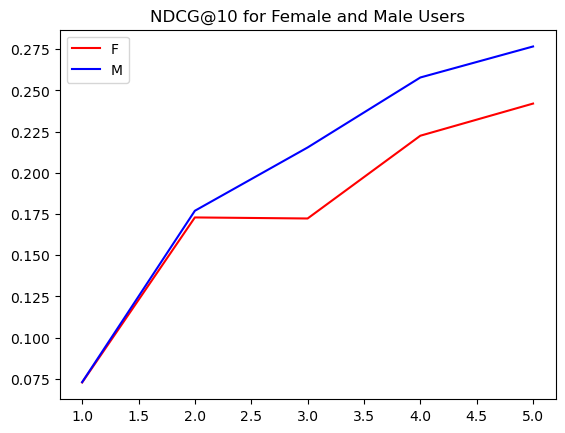

In [65]:
plt.plot(np.arange(1,6), ndcg_results[:, 0], label='F', c='r')
plt.plot(np.arange(1,6), ndcg_results[:, 1], label='M', c='b')
plt.title("NDCG@10 for Female and Male Users")
plt.legend()
plt.show()

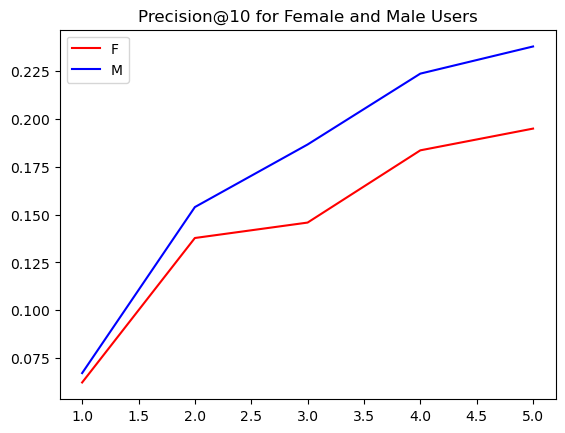

In [71]:
plt.plot(np.arange(1,6), precision_results[:, 0], label='F', c='r')
plt.plot(np.arange(1,6), precision_results[:, 1], label='M', c='b')
plt.title("Precision@10 for Female and Male Users")
plt.legend()
plt.show()

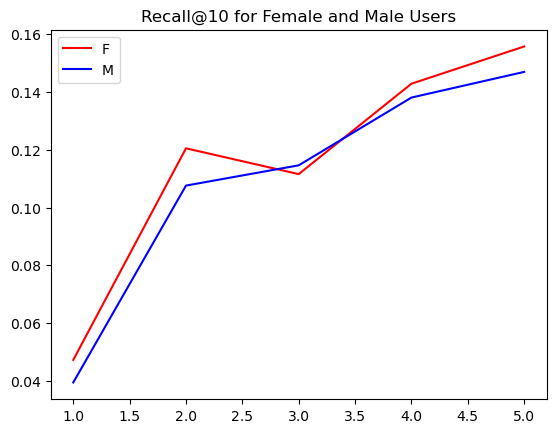

In [73]:
plt.plot(np.arange(1,6), recall_results[:, 0], label='F', c='r')
plt.plot(np.arange(1,6), recall_results[:, 1], label='M', c='b')
plt.title("Recall@10 for Female and Male Users")
plt.legend()
plt.show()